In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [6]:
import seaborn as sns
iris = sns.load_dataset("iris")

data = torch.tensor( iris[iris.columns[0:4]].values ).float()

labels = torch.zeros( len(data), dtype=torch.long )
labels[iris.species=="versicolor"] = 1
labels[iris.species=="virginica"] = 2

In [7]:
# Split the data
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, train_size=0.8
)

# Convert them into Pytorch Datasets
train_data = torch.utils.data.TensorDataset(train_data, train_labels)
test_data = torch.utils.data.TensorDataset(test_data, test_labels)

# Translate into Dataloaders
train_loader = DataLoader(train_data, shuffle=True, batch_size=12)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [10]:
def createANewModel():
    ANNiris = nn.Sequential(
        nn.Linear(4, 64), # input layer
        nn.ReLU(), # activation layer
        nn.Linear(64, 64), # hidden layer
        nn.ReLU(), # activation unit
        nn.Linear(64, 3), # output units
    )
    
    lossfun = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.SGD(ANNiris.parameters(), lr=0.01)

    return ANNiris, lossfun, optimizer

In [11]:
numepochs = 500

def trainTheModel():

    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        batchAcc = []
        for X, y in train_loader:

            yHat = ANNiris(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchAcc.append( 100*torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())

            trainAcc.append( np.mean(batchAcc) )

            X, y = next( iter(test_loader) )
            predlabels = torch.argmax( ANNiris(X), axis=1 )
            testAcc.append( 100*torch.mean((predlabels == y).float()).item() )

    return trainAcc, testAcc

In [12]:
ANNiris, lossfun, optimizer = createANewModel()

trainAcc, testAcc = trainTheModel()

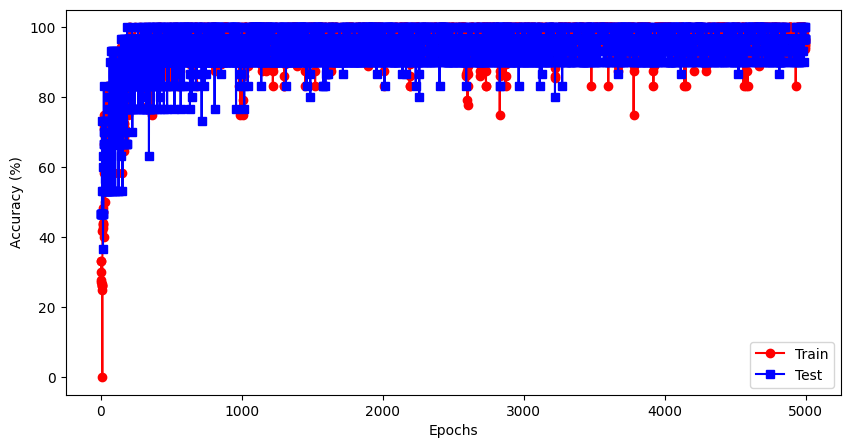

In [13]:
fig = plt.figure(figsize=(10,5))

plt.plot(trainAcc, 'ro-')
plt.plot(testAcc, 'bs-')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(['Train', 'Test'])